# 05 Sentiment and Impact Analysis

This notebook analyzes topic-level, entity-level, and industry-level sentiment patterns from `040_sentiment.parquet`.

Questions covered:
- overall sentiment distribution
- topic-level sentiment patterns
- entity-level sentiment for organizations and technologies
- industry-level sentiment patterns
- disagreement between `sentiment` and `impact`
- high-confidence positive sentiment cases where `impact <= 0`


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

sns.set_theme(style="whitegrid")


def split_items(value, extra_delimiters=None):
    if pd.isna(value):
        return []
    text = str(value)
    for delimiter in extra_delimiters or []:
        text = text.replace(delimiter, ",")
    return [item.strip() for item in text.split(",") if item.strip()]

def impact_to_sentiment(series):
    return np.select(
        [series.gt(0), series.lt(0)],
        ["positive", "negative"],
        default="neutral",
    )


## 1. Load cleaned dataset

In [2]:
SENTIMENT_ORDER = ["negative", "neutral", "positive"]

df = pd.read_parquet("040_sentiment.parquet").copy()
df = df[df['cluster'] != -1]
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["sentiment"] = pd.Categorical(df["sentiment"], categories=SENTIMENT_ORDER, ordered=True)
df["impact_sentiment"] = impact_to_sentiment(df["impact"])

print(df.shape)
display(df.head())

(106367, 12)


,date,title,summary,organization,industry,impact,technology,cluster,topic,sentiment,score,impact_sentiment
2,2024-09-22,"If using AI feels like a chore, try this - Boi...",1minAI offers a lifetime subscription for $39....,1minAI,Software,1,"GPT-4, Gemini Pro, Claude",1292,AI tools and services with lifetime or discoun...,neutral,0.990789,positive
6,2023-09-07,Zoom Expands AI Offering with AI Companion and...,Zoom is enhancing its platform with two new AI...,Zoom,Technology,1,Generative AI,187,AI integration in business software,positive,0.982762,positive
9,2025-12-15,State AGs Warn AI Companies: Clean Up Your Chi...,Dozens of state Attorneys General have warned ...,"OpenAI, Microsoft",Technology,-1,AI,887,AI chatbots face scrutiny over child safety an...,negative,0.938915,negative
10,2023-07-26,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,Bullfrog AI Holdings Inc. [BFRG] announced the...,Bullfrog AI Holdings Inc.,Pharmaceuticals,1,AI,232,"Bullfrog AI Holdings, Inc. stock and business ...",positive,0.977615,positive
11,2025-10-27,Qualcomm announces new AI chips in data center...,"Qualcomm has announced two new AI chips, the A...",Qualcomm,Semiconductors,1,AI chips,1215,Qualcomm's AI advancements and market performance,positive,0.993401,positive


## 2. Analyze overall sentiment distribution

,sentiment,count,share
0,negative,19746,0.185640
1,neutral,40409,0.379902
2,positive,46212,0.434458


/var/folders/k4/tvw2_4hs615cgbdrbjzqhybw0000gn/T/ipykernel_47037/2344958199.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=overall, x="sentiment", y="count", palette="RdYlGn")


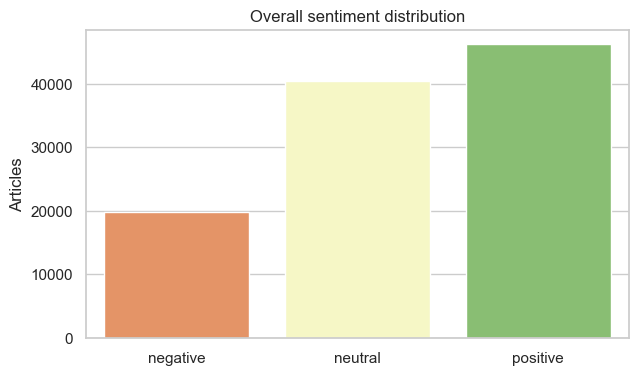

In [3]:
overall = (
    df["sentiment"]
    .value_counts(dropna=False)
    .reindex(SENTIMENT_ORDER)
    .rename_axis("sentiment")
    .reset_index(name="count")
)
overall["share"] = overall["count"] / len(df)
display(overall)

plt.figure(figsize=(7, 4))
sns.barplot(data=overall, x="sentiment", y="count", palette="RdYlGn")
plt.title("Overall sentiment distribution")
plt.xlabel("")
plt.ylabel("Articles")
plt.show()

## 3. Aggregate sentiment at the topic level

,topic,article_count,avg_impact,positive_share,negative_share,neutral_share
670,AI-generated images from rawpixel.com,1167,0.292202,0.000000,0.000000,1.000000
511,AI startups securing funding for diverse appli...,1028,1.227626,0.935798,0.006809,0.057393
1088,Global AI events and strategies,1016,0.833661,0.063976,0.000984,0.935039
422,AI integration in education,1004,0.234064,0.186255,0.346614,0.467131
1361,Nvidia's dominance in the AI chip market,659,1.644917,0.822458,0.160850,0.016692
14,AI Enhances Cybersecurity Solutions,576,1.338542,0.802083,0.003472,0.194444
556,AI video generation tools,573,1.246073,0.253054,0.001745,0.745201
313,AI in cancer detection and treatment,562,1.594306,0.895018,0.000000,0.104982
1022,Edge AI hardware and platforms,518,1.113900,0.712355,0.001931,0.285714
327,AI in education and learning,471,1.114650,0.600849,0.016985,0.382166


/var/folders/k4/tvw2_4hs615cgbdrbjzqhybw0000gn/T/ipykernel_47037/3565752951.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=topic_plot, y="topic", x="avg_impact", palette="vlag")


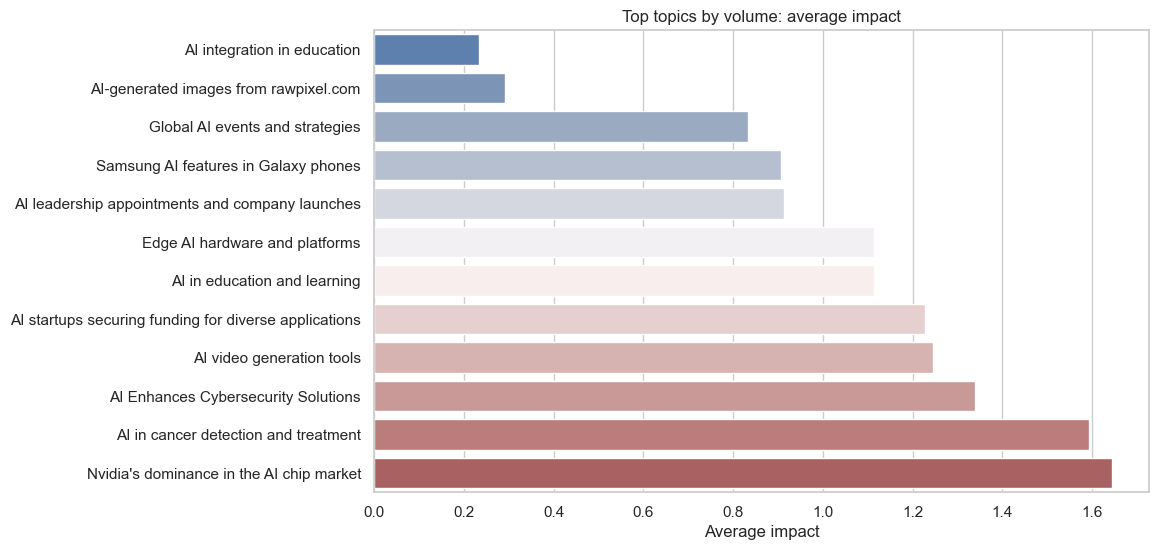

In [4]:
topic_stats = (
    df.groupby("topic", as_index=False)
    .agg(
        article_count=("title", "size"),
        avg_impact=("impact", "mean"),
        positive_share=("sentiment", lambda s: (s == "positive").mean()),
        negative_share=("sentiment", lambda s: (s == "negative").mean()),
        neutral_share=("sentiment", lambda s: (s == "neutral").mean()),
    )
    .sort_values(["article_count", "avg_impact"], ascending=[False, False])
)

display(topic_stats.head(15))

topic_plot = topic_stats.nlargest(12, "article_count").sort_values("avg_impact")
plt.figure(figsize=(10, 6))
sns.barplot(data=topic_plot, y="topic", x="avg_impact", palette="vlag")
plt.title("Top topics by volume: average impact")
plt.xlabel("Average impact")
plt.ylabel("")
plt.show()

## 4. Analyze sentiment at the entity level

In [5]:
org_df = df[["organization", "sentiment", "impact", "score"]].copy()
org_df["organization"] = org_df["organization"].apply(lambda x: split_items(x, extra_delimiters=[";"]))
org_df = org_df.explode("organization").dropna(subset=["organization"])

org_stats = (
    org_df.groupby("organization", as_index=False)
    .agg(
        mention_count=("organization", "size"),
        avg_impact=("impact", "mean"),
        positive_share=("sentiment", lambda s: (s == "positive").mean()),
        netural_share=("sentiment", lambda s: (s == "neutral").mean()),
        negative_share=("sentiment", lambda s: (s == "negative").mean()),
    )
    .query("mention_count >= 10")
    .sort_values(["mention_count", "avg_impact"], ascending=[False, False])
)

tech_df = df[["technology", "sentiment", "impact", "score"]].copy()
tech_df["technology"] = tech_df["technology"].apply(lambda x: split_items(x, extra_delimiters=[";", " and "]))
tech_df = tech_df.explode("technology").dropna(subset=["technology"])

tech_stats = (
    tech_df.groupby("technology", as_index=False)
    .agg(
        mention_count=("technology", "size"),
        avg_impact=("impact", "mean"),
        positive_share=("sentiment", lambda s: (s == "positive").mean()),
        netural_share=("sentiment", lambda s: (s == "neutral").mean()),
        negative_share=("sentiment", lambda s: (s == "negative").mean()),
    )
    .query("mention_count >= 10")
    .sort_values(["mention_count", "avg_impact"], ascending=[False, False])
)

display(org_stats.head(15))
display(tech_stats.head(15))

,organization,mention_count,avg_impact,positive_share,netural_share,negative_share
15215,OpenAI,9432,0.220844,0.328244,0.347328,0.324427
24998,rawpixel.com,4468,0.297001,0.000000,1.000000,0.000000
9014,Google,4424,0.393535,0.425859,0.312161,0.261980
13395,Microsoft,3550,0.643099,0.527606,0.254648,0.217746
14903,Nvidia,1869,1.110754,0.682718,0.099518,0.217764
13286,Meta,1740,0.421839,0.446552,0.313218,0.240230
4416,ChatGPT,1516,0.263193,0.257256,0.435356,0.307388
1988,Apple,1479,0.594997,0.471264,0.267072,0.261663
1702,Amazon,1134,0.659612,0.581129,0.214286,0.204586
17852,Samsung,806,0.853598,0.521092,0.392060,0.086849


,technology,mention_count,avg_impact,positive_share,netural_share,negative_share
47,AI,60304,0.456520,0.393357,0.416938,0.189705
4445,ChatGPT,4936,0.149311,0.303890,0.405794,0.290316
5402,Generative AI,4838,0.786689,0.587640,0.276974,0.135387
7846,generative AI,2009,0.701842,0.590343,0.231458,0.178198
1051,AI chatbot,1742,-0.012055,0.328358,0.281286,0.390356
4148,Artificial Intelligence,1295,0.703475,0.535907,0.336680,0.127413
1109,AI chips,1256,0.839172,0.645701,0.070064,0.284236
8046,machine learning,1237,1.122878,0.679062,0.289410,0.031528
1069,AI chatbots,666,-0.363363,0.192192,0.388889,0.418919
5968,Machine Learning,614,1.039088,0.527687,0.418567,0.053746


/var/folders/k4/tvw2_4hs615cgbdrbjzqhybw0000gn/T/ipykernel_47037/3464513145.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=org_plot, y="organization", x="avg_impact", palette="vlag", ax=axes[0])
/var/folders/k4/tvw2_4hs615cgbdrbjzqhybw0000gn/T/ipykernel_47037/3464513145.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tech_plot, y="technology", x="avg_impact", palette="vlag", ax=axes[1])


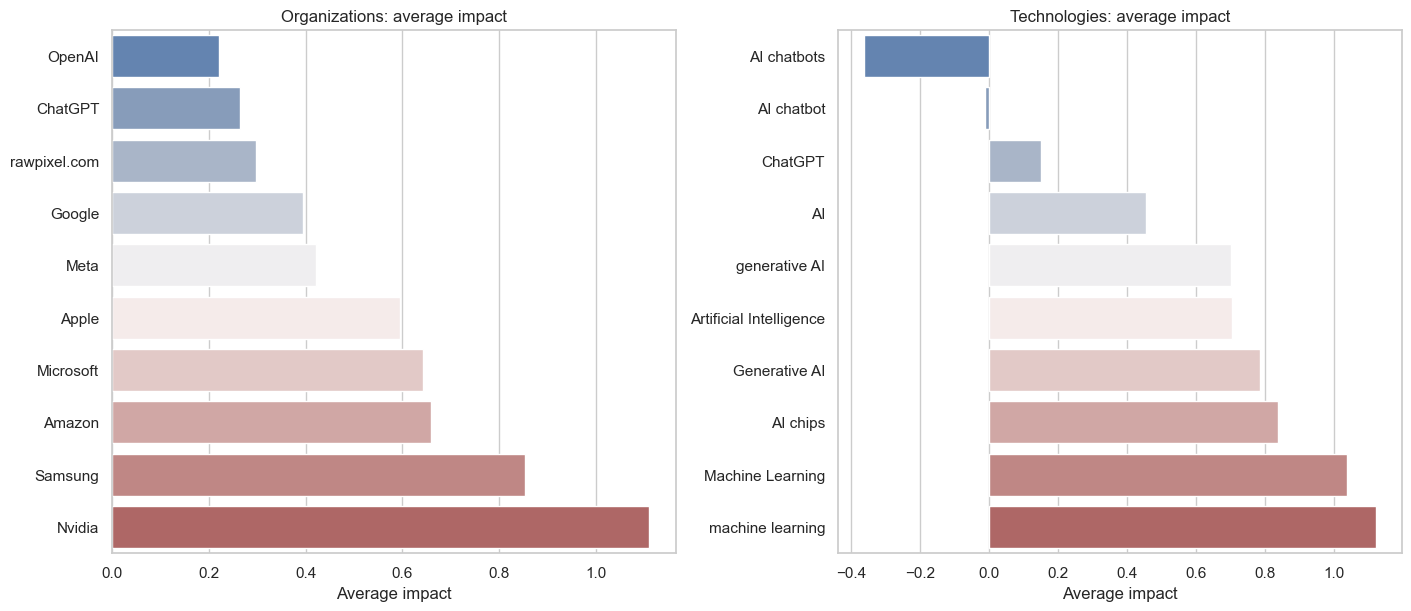

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

org_plot = org_stats.nlargest(10, "mention_count").sort_values("avg_impact")
sns.barplot(data=org_plot, y="organization", x="avg_impact", palette="vlag", ax=axes[0])
axes[0].set_title("Organizations: average impact")
axes[0].set_xlabel("Average impact")
axes[0].set_ylabel("")

tech_plot = tech_stats.nlargest(10, "mention_count").sort_values("avg_impact")
sns.barplot(data=tech_plot, y="technology", x="avg_impact", palette="vlag", ax=axes[1])
axes[1].set_title("Technologies: average impact")
axes[1].set_xlabel("Average impact")
axes[1].set_ylabel("")

plt.show()

## 5. Examine industry-level sentiment patterns

,industry,article_count,avg_impact,avg_score,positive_share,netural_share,negative_share
5711,Technology,32134,0.492842,0.884461,0.447750,0.312535,0.239715
2151,Education,3294,0.570128,0.864894,0.292653,0.536126,0.171220
3051,Healthcare,3154,1.162334,0.914611,0.716550,0.200380,0.083069
1237,Consumer Electronics,1982,0.903128,0.897563,0.375378,0.575177,0.049445
2528,Finance,1982,0.441978,0.936517,0.378406,0.429364,0.192230
5400,Social Media,1894,-0.063358,0.855439,0.255544,0.425026,0.319430
2873,Government,1543,0.219054,0.855510,0.290343,0.504861,0.204796
2372,Entertainment,1344,-0.325149,0.844921,0.208333,0.479167,0.312500
3931,Media,1242,-0.272142,0.863298,0.165056,0.527375,0.307568
1578,Cybersecurity,1197,0.155388,0.884484,0.547201,0.290727,0.162072


/var/folders/k4/tvw2_4hs615cgbdrbjzqhybw0000gn/T/ipykernel_47037/1689148635.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=industry_plot, y="industry", x="avg_impact", palette="vlag")


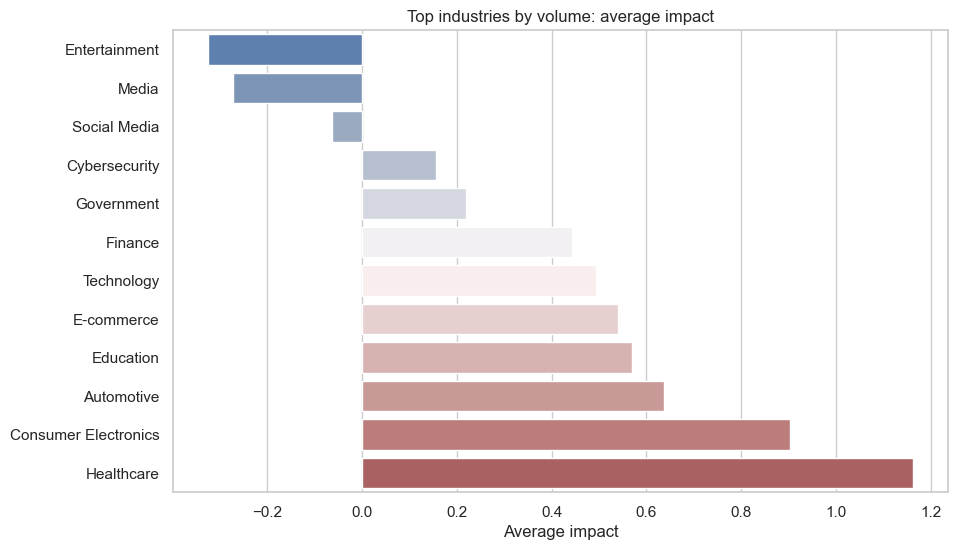

In [7]:
industry_stats = (
    df.groupby("industry", as_index=False)
    .agg(
        article_count=("title", "size"),
        avg_impact=("impact", "mean"),
        avg_score=("score", "mean"),
        positive_share=("sentiment", lambda s: (s == "positive").mean()),
        netural_share=("sentiment", lambda s: (s == "neutral").mean()),
        negative_share=("sentiment", lambda s: (s == "negative").mean()),
    )
    .query("article_count >= 20")
    .sort_values(["article_count", "avg_impact"], ascending=[False, False])
)

display(industry_stats.head(20))

industry_plot = industry_stats.nlargest(12, "article_count").sort_values("avg_impact")
plt.figure(figsize=(10, 6))
sns.barplot(data=industry_plot, y="industry", x="avg_impact", palette="vlag")
plt.title("Top industries by volume: average impact")
plt.xlabel("Average impact")
plt.ylabel("")
plt.show()

## 6. Compare sentiment with impact

Disagreement rows: 37,458 / 106,367 (35.22%)


sentiment,negative,neutral,positive,All
impact_sentiment,,,,
negative,12599,4995,1227,18821
neutral,4713,13787,2462,20962
positive,2434,21627,42523,66584
All,19746,40409,46212,106367


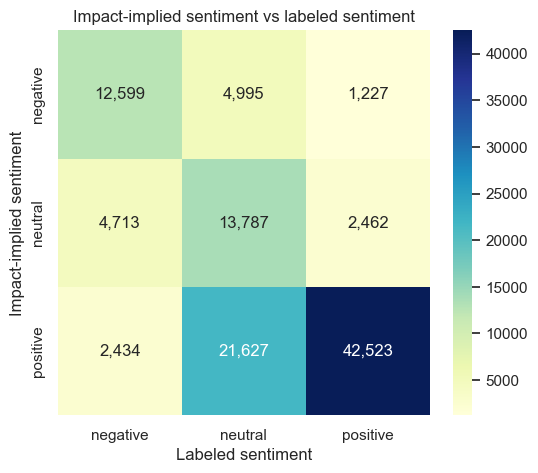

In [8]:
impact_vs_sentiment = pd.crosstab(df["impact_sentiment"], df["sentiment"], margins=True)
disagreement = df.loc[df["impact_sentiment"] != df["sentiment"]].copy()
disagreement_rate = len(disagreement) / len(df)

print(f"Disagreement rows: {len(disagreement):,} / {len(df):,} ({disagreement_rate:.2%})")
display(impact_vs_sentiment)

plt.figure(figsize=(6, 5))
sns.heatmap(pd.crosstab(df["impact_sentiment"], df["sentiment"]), annot=True, fmt=",d", cmap="YlGnBu")
plt.title("Impact-implied sentiment vs labeled sentiment")
plt.xlabel("Labeled sentiment")
plt.ylabel("Impact-implied sentiment")
plt.show()

In [9]:
high_conf_positive_conflict = (
    df.loc[
        (df["sentiment"] == "positive")
        & (df["score"] >= 0.99)
        & (df["impact"] <= 0),
        ["date", "title", 'summary', "organization", "industry", "technology", "topic", "sentiment", "score", "impact"],
    ]
    .sort_values(["score", "impact"], ascending=[False, True])
)

conflict_summary = (
    high_conf_positive_conflict.groupby("impact", as_index=False)
    .agg(case_count=("title", "size"))
    .sort_values("impact")
)

print(f"Positive + score >= 0.99 + impact <= 0 cases: {len(high_conf_positive_conflict):,}")
display(conflict_summary)
display(high_conf_positive_conflict.head(20))

Positive + score >= 0.99 + impact <= 0 cases: 260


,impact,case_count
0,-2,33
1,-1,27
2,0,200


,date,title,summary,organization,industry,technology,topic,sentiment,score,impact
159616,2025-06-25,Aurora Private Wealth Inc. Grows Holdings in T...,Aurora Private Wealth Inc. significantly incre...,Aurora Private Wealth Inc.,Financial Services,AI,AI ETFs see institutional investment shifts,positive,0.994147,0
10394,2022-03-23,Meta Platforms Inc. (NASDAQ:FB) Stock Position...,Bard Financial Services Inc. increased its sta...,Meta Platforms,Financial Services,AI,Bard Financial Services investment activity,positive,0.993930,0
20239,2023-04-05,Broadcom Inc. (NASDAQ:AVGO) Shares Bought by B...,Bard Financial Services Inc. increased its sta...,Broadcom Inc.,Technology,AI,Bard Financial Services investment activity,positive,0.993886,0
140564,2025-03-20,Farther Finance Advisors LLC Increases Stake i...,Farther Finance Advisors LLC significantly inc...,Farther Finance Advisors LLC,Financial Services,AI,AI and Robotics ETF Activity,positive,0.993865,0
78587,2026-01-21,Global PC Shipments Up 9.3 Pc In Oct-Dec In AI...,Global PC shipments increased by 9.3% in the f...,,Technology,AI PCs,AI PCs driving market growth and enterprise ad...,positive,0.993696,0
146020,2025-05-16,Canadian Gold Corp. Signs Definitive Agreement...,Canadian Gold Corp. has signed an option agree...,Hudbay Minerals Inc.,Mining,AI,Mining companies report new gold and silver di...,positive,0.993588,0
65667,2023-11-15,An excellent week for The GPT Group's (ASX:GPT...,"The GPT Group's institutional owners, holding ...",The GPT Group,Finance,AI,GPT and related company news,positive,0.993580,0
11367,2023-01-05,Sargent Investment Group LLC Buys 665 Shares o...,Sargent Investment Group LLC has increased its...,Sargent Investment Group LLC,Finance,AI,AI and Robotics ETF Activity,positive,0.993546,0
79171,2025-10-19,"Report: Higher phishing success, profitability...",AI-generated phishing emails are significantly...,Nation-state actors,Cybersecurity,AI,AI-powered cybercrime and security threats,positive,0.993454,-2
123494,2022-02-03,Link Machine Learning 24 Hour Trading Volume R...,Link Machine Learning (LML) experienced a 1.4%...,Link Machine Learning (LML),cryptocurrency,AI,Cryptocurrency price fluctuations,positive,0.993334,0


In [10]:
for idx, row in high_conf_positive_conflict.head(20).iterrows():
    print(f"Impact: {row['impact']:2d} | Sentiment: {row['sentiment']:8s} | Score: {row['score']:.4f}")
    print(f"Summary: {row['summary']}")
    print("-" * 100)

Impact:  0 | Sentiment: positive | Score: 0.9941
Summary: Aurora Private Wealth Inc. significantly increased its stake in the TCW Artificial Intelligence ETF (AIFD) during the first quarter, acquiring an additional 423,961 shares. This move represents a substantial growth in their holdings, now accounting for 0.20% of the ETF's value.
----------------------------------------------------------------------------------------------------
Impact:  0 | Sentiment: positive | Score: 0.9939
Summary: Bard Financial Services Inc. increased its stake in Meta Platforms (FB) by 5.0% in the fourth quarter, acquiring an additional 575 shares. Several other institutional investors also boosted their holdings in Meta Platforms during the same period.
----------------------------------------------------------------------------------------------------
Impact:  0 | Sentiment: positive | Score: 0.9939
Summary: Bard Financial Services Inc. increased its stake in Broadcom Inc. by 36.7% in the fourth quarter, 

## 7. Interpret insights about AI impact

Key takeaways
1. Overall sentiment is led by 'positive'.
2. Most positive topic by average impact: Nvidia's dominance in AI chips (2.00, n=22).
3. Most negative topic by average impact: AI existential risks and mitigation (-2.00, n=68).
4. Most positive industry by average impact: Weather Forecasting (1.78, n=27).
5. Most negative industry by average impact: Fraud (-2.00, n=24).
6. Sentiment-impact disagreement appears in 35.22% of rows, so tone and measured impact do not always align.
7. There are 260 high-confidence positive rows with non-positive impact, which are worth manual review.

In [12]:
# top_positive_topic = topic_stats.loc[topic_stats["avg_impact"].idxmax(), ["topic", "avg_impact", "article_count"]]
# top_negative_topic = topic_stats.loc[topic_stats["avg_impact"].idxmin(), ["topic", "avg_impact", "article_count"]]
# top_positive_industry = industry_stats.loc[industry_stats["avg_impact"].idxmax(), ["industry", "avg_impact", "article_count"]]
# top_negative_industry = industry_stats.loc[industry_stats["avg_impact"].idxmin(), ["industry", "avg_impact", "article_count"]]

# print("Key takeaways")
# print(f"1. Overall sentiment is led by '{overall.loc[overall['count'].idxmax(), 'sentiment']}'.")
# print(f"2. Most positive topic by average impact: {top_positive_topic['topic']} ({top_positive_topic['avg_impact']:.2f}, n={int(top_positive_topic['article_count'])}).")
# print(f"3. Most negative topic by average impact: {top_negative_topic['topic']} ({top_negative_topic['avg_impact']:.2f}, n={int(top_negative_topic['article_count'])}).")
# print(f"4. Most positive industry by average impact: {top_positive_industry['industry']} ({top_positive_industry['avg_impact']:.2f}, n={int(top_positive_industry['article_count'])}).")
# print(f"5. Most negative industry by average impact: {top_negative_industry['industry']} ({top_negative_industry['avg_impact']:.2f}, n={int(top_negative_industry['article_count'])}).")
# print(f"6. Sentiment-impact disagreement appears in {disagreement_rate:.2%} of rows, so tone and measured impact do not always align.")
# print(f"7. There are {len(high_conf_positive_conflict):,} high-confidence positive rows with non-positive impact, which are worth manual review.")